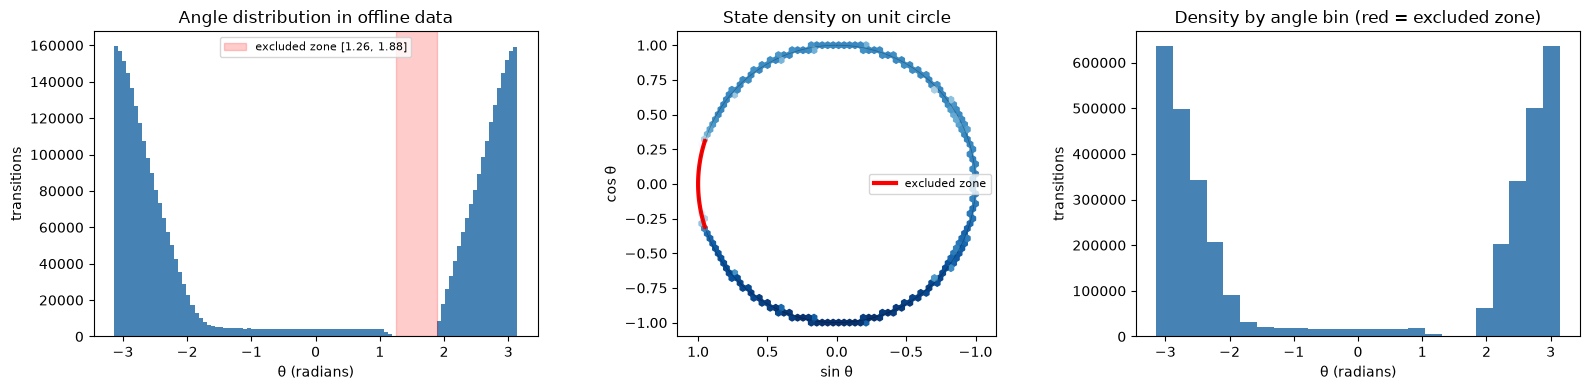

Total transitions: 3732139
In excluded zone: 279
In mirror zone:   67130


In [3]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from denrl.env import obs_to_theta, ZONE_LOW, ZONE_HIGH

df = pd.read_parquet('data/E1_offline.parquet')
obs = df[['obs0', 'obs1', 'obs2']].to_numpy()
thetas = np.array([obs_to_theta(o) for o in obs])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Angle histogram
ax = axes[0]
ax.hist(thetas, bins=100, color='steelblue', edgecolor='none')
ax.axvspan(ZONE_LOW, ZONE_HIGH, color='red', alpha=0.2, label=f'excluded zone [{ZONE_LOW:.2f}, {ZONE_HIGH:.2f}]')
ax.set_xlabel('θ (radians)')
ax.set_ylabel('transitions')
ax.set_title('Angle distribution in offline data')
ax.legend(fontsize=8)

# 2) 2D scatter on unit circle (sin θ vs cos θ)
ax = axes[1]
ax.hexbin(obs[:, 1], obs[:, 0], gridsize=50, cmap='Blues', mincnt=1, bins='log')
zone_th = np.linspace(ZONE_LOW, ZONE_HIGH, 100)
ax.plot(np.sin(zone_th), np.cos(zone_th), 'r-', lw=3, label='excluded zone')
circle = np.linspace(0, 2*np.pi, 300)
ax.plot(np.sin(circle), np.cos(circle), 'k-', lw=0.5, alpha=0.3)
ax.set_xlabel('sin θ')
ax.set_ylabel('cos θ')
ax.set_title('State density on unit circle')
ax.set_aspect('equal')
ax.set_xlim(1.15, -1.15)
ax.legend(fontsize=8)

# 3) Density by angle bin (bar chart)
ax = axes[2]
bin_edges = np.linspace(-np.pi, np.pi, 25)
counts, _ = np.histogram(thetas, bins=bin_edges)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
colors = ['red' if ZONE_LOW <= c <= ZONE_HIGH else 'steelblue' for c in centers]
ax.bar(centers, counts, width=bin_edges[1]-bin_edges[0], color=colors, edgecolor='none')
ax.set_xlabel('θ (radians)')
ax.set_ylabel('transitions')
ax.set_title('Density by angle bin (red = excluded zone)')

plt.tight_layout()
plt.show()

print(f'Total transitions: {len(df)}')
print(f'In excluded zone: {np.sum((thetas >= ZONE_LOW) & (thetas <= ZONE_HIGH))}')
print(f'In mirror zone:   {np.sum((thetas >= -ZONE_HIGH) & (thetas <= -ZONE_LOW))}')

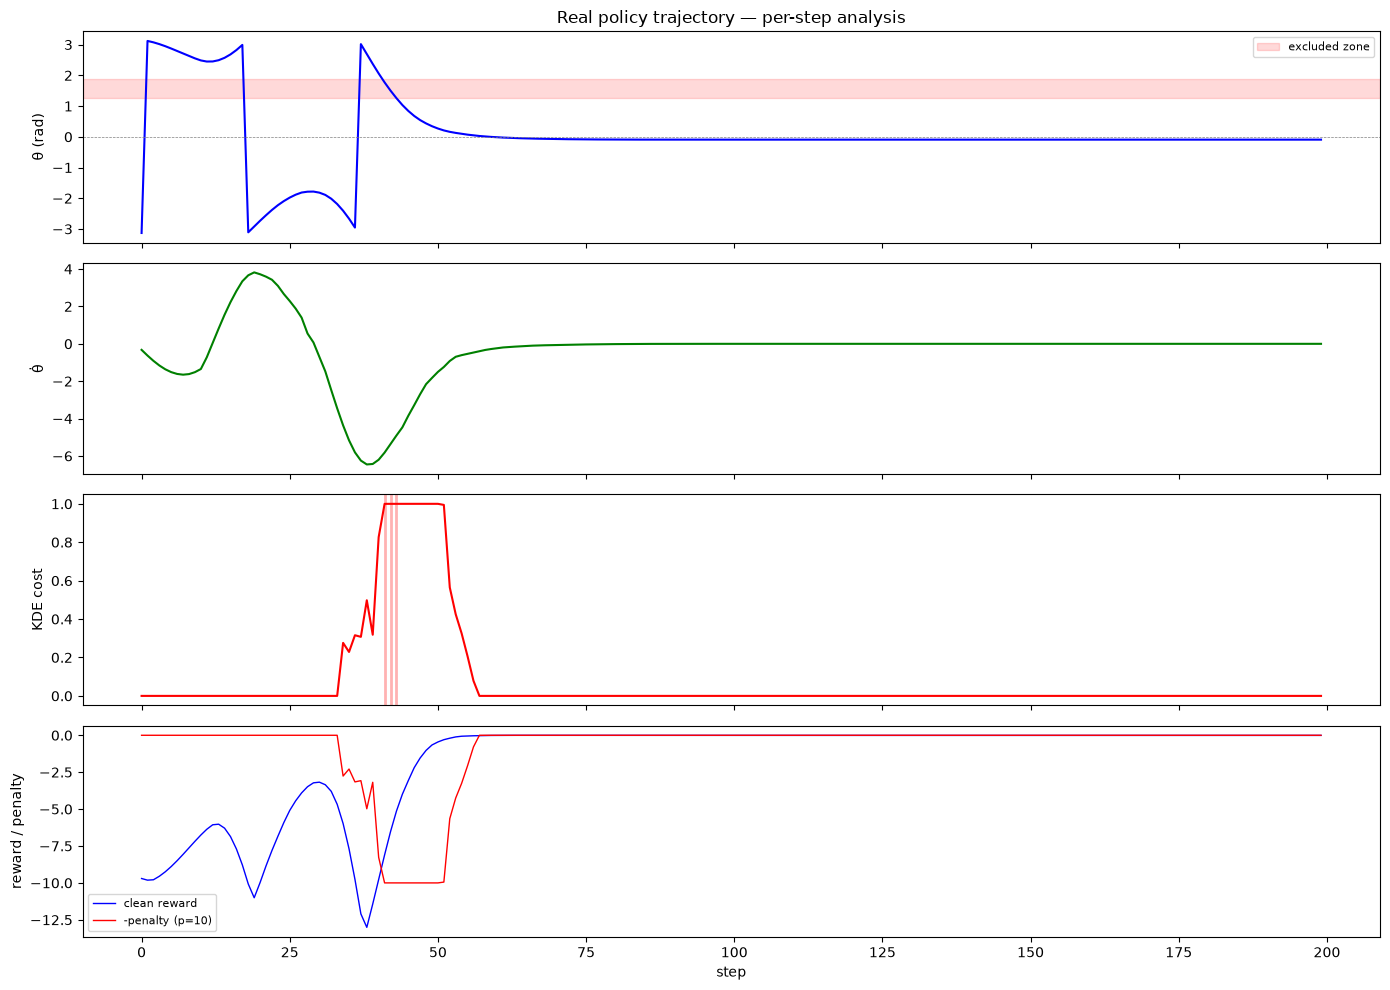

Total clean reward: -343.2
Total penalty:      153.6
Zone steps:         3
Steps with cost>0:  23


In [5]:
import sys
sys.path.insert(0, '.')
import numpy as np
import yaml
import pandas as pd
from denrl.env import make_sim_env, obs_to_theta, Zone, ZONE_LOW, ZONE_HIGH
from denrl.costs import KDEDensityCost
from stable_baselines3 import SAC

# Load policy
run_dir = 'runs/baseline_E1_seed0'
cfg = yaml.safe_load(open(f'{run_dir}/config.yaml'))
model = SAC.load(f'{run_dir}/policy', env=None)
env = make_sim_env(cfg['env'])

# Fit KDE
df = pd.read_parquet('data/E1_offline.parquet')
dataset = {
    'obs': df[['obs0','obs1','obs2']].to_numpy(),
    'act': df[['act0']].to_numpy(),
    'next_obs': df[['next0','next1','next2']].to_numpy(),
}
kde = KDEDensityCost(bandwidth=0.1, ref_percentile=5.0)
kde.fit(dataset)

zone = Zone(ZONE_LOW, ZONE_HIGH)
p = 10

# Roll out one episode — real trajectory
obs, _ = env.reset(seed=42)
steps, thetas, thdots, costs, penalties, rewards, in_zones = [], [], [], [], [], [], []
for t in range(200):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, term, trunc, _ = env.step(action)
    th = obs_to_theta(obs)
    c = kde.cost(obs, action)
    iz = zone.contains(obs)
    steps.append(t)
    thetas.append(th)
    thdots.append(obs[2])
    costs.append(c)
    penalties.append(p * c)
    rewards.append(reward)
    in_zones.append(iz)
    if term or trunc:
        break

import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# 1) Angle over time
ax = axes[0]
ax.plot(steps, thetas, 'b-', lw=1.5)
ax.axhspan(ZONE_LOW, ZONE_HIGH, color='red', alpha=0.15, label='excluded zone')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('θ (rad)')
ax.set_title('Real policy trajectory — per-step analysis')
ax.legend(fontsize=8)

# 2) Velocity
ax = axes[1]
ax.plot(steps, thdots, 'g-', lw=1.5)
ax.set_ylabel('θ̇')

# 3) KDE cost
ax = axes[2]
ax.plot(steps, costs, 'r-', lw=1.5)
for t, iz in zip(steps, in_zones):
    if iz:
        ax.axvline(t, color='red', alpha=0.3, lw=2)
ax.set_ylabel('KDE cost')

# 4) Penalty vs reward
ax = axes[3]
ax.plot(steps, rewards, 'b-', lw=1, label='clean reward')
ax.plot(steps, [-p for p in penalties], 'r-', lw=1, label=f'-penalty (p={p})')
ax.set_ylabel('reward / penalty')
ax.set_xlabel('step')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Total clean reward: {sum(rewards):.1f}')
print(f'Total penalty:      {sum(penalties):.1f}')
print(f'Zone steps:         {sum(in_zones)}')
print(f'Steps with cost>0:  {sum(1 for c in costs if c > 0.01)}')

In [4]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
from denrl.costs import KDEDensityCost
from denrl.env import obs_to_theta, Zone, ZONE_LOW, ZONE_HIGH

# Fit KDE on offline data
df = pd.read_parquet('data/E1_offline.parquet')
dataset = {
    'obs': df[['obs0','obs1','obs2']].to_numpy(),
    'act': df[['act0']].to_numpy(),
    'next_obs': df[['next0','next1','next2']].to_numpy(),
}
kde = KDEDensityCost(bandwidth=0.1, ref_percentile=5.0)
kde.fit(dataset)

zone = Zone(ZONE_LOW, ZONE_HIGH)
p = 10

# Simulate both paths with realistic velocities
print('=== Zone path (θ: π → 0, decreasing) ===')
zone_total_cost = 0
zone_total_reward = 0
zone_total_penalty = 0
for th in np.linspace(np.pi, 0, 50):
    thdot = -4.0  # realistic swing velocity
    obs = np.array([np.cos(th), np.sin(th), thdot])
    c = kde.cost(obs, np.array([0.0]))
    r = -(th**2 + 0.1*thdot**2)
    iz = zone.contains(obs)
    penalty = p * c
    zone_total_cost += c
    zone_total_reward += r
    zone_total_penalty += penalty
    if iz:
        print(f'  θ={th:+.3f}  cost={c:.3f}  penalty={penalty:.1f}  reward={r:.1f}  IN ZONE')

print(f'  Total: reward={zone_total_reward:.0f}  penalty={zone_total_penalty:.0f}  net={zone_total_reward - zone_total_penalty:.0f}')

print()
print('=== Safe path (θ: π → -π → 0, increasing) ===')
safe_total_cost = 0
safe_total_reward = 0
safe_total_penalty = 0
for th_raw in np.linspace(np.pi, 2*np.pi, 50):
    th = th_raw - 2*np.pi if th_raw > np.pi else th_raw
    th_for_reward = min(abs(th_raw - 2*np.pi), abs(th_raw))
    thdot = 4.0
    obs = np.array([np.cos(th_raw), np.sin(th_raw), thdot])
    c = kde.cost(obs, np.array([0.0]))
    r = -(th_for_reward**2 + 0.1*thdot**2)
    iz = zone.contains(obs)
    penalty = p * c
    safe_total_cost += c
    safe_total_reward += r
    safe_total_penalty += penalty

print(f'  Total: reward={safe_total_reward:.0f}  penalty={safe_total_penalty:.0f}  net={safe_total_reward - safe_total_penalty:.0f}')
print()
print(f'Zone path net:  {zone_total_reward - zone_total_penalty:.0f}')
print(f'Safe path net:  {safe_total_reward - safe_total_penalty:.0f}')
print(f'Difference: {(safe_total_reward - safe_total_penalty) - (zone_total_reward - zone_total_penalty):.0f} (positive = safe is better)')

=== Zone path (θ: π → 0, decreasing) ===
  θ=+1.859  cost=0.958  penalty=9.6  reward=-5.1  IN ZONE
  θ=+1.795  cost=0.992  penalty=9.9  reward=-4.8  IN ZONE
  θ=+1.731  cost=0.999  penalty=10.0  reward=-4.6  IN ZONE
  θ=+1.667  cost=1.000  penalty=10.0  reward=-4.4  IN ZONE
  θ=+1.603  cost=1.000  penalty=10.0  reward=-4.2  IN ZONE
  θ=+1.539  cost=1.000  penalty=10.0  reward=-4.0  IN ZONE
  θ=+1.475  cost=1.000  penalty=10.0  reward=-3.8  IN ZONE
  θ=+1.411  cost=1.000  penalty=10.0  reward=-3.6  IN ZONE
  θ=+1.346  cost=1.000  penalty=10.0  reward=-3.4  IN ZONE
  θ=+1.282  cost=1.000  penalty=10.0  reward=-3.2  IN ZONE
  Total: reward=-246  penalty=318  net=-564

=== Safe path (θ: π → -π → 0, increasing) ===
  Total: reward=-246  penalty=342  net=-588

Zone path net:  -564
Safe path net:  -588
Difference: -24 (positive = safe is better)


## TODO
- Investigate Lagrangian with continuous cost (no threshold) — does the 2D KDE fix (dropping θ̇) make the continuous cost work for Lagrangian? The zone cost should now be much higher than the safe path since the KDE only looks at position.
- If continuous still doesn't work: try **threshold + continuous below** mode for Lagrangian: density ≥ 0.025 → cost = 0, density < 0.025 → cost = continuous (scaled by how far below threshold). This gives gradient info for α calibration while keeping the safe path penalty-free.
- Compare: baseline (threshold + fixed p) vs Lagrangian (continuous + adaptive α) vs Lagrangian (threshold+continuous + adaptive α)